# Funnel Tree — đọc code từng bước

Notebook này giải thích **flow** của `src/my/algorithm1.py` (bản Python của bạn) bằng hình vẽ, không đọc code khô.

Cách dùng: đọc từ trên xuống, **chạy từng ô** (`Shift+Enter`). Mỗi ô độc lập, không phụ thuộc thứ tự chạy.

> **Bài báo:** Phan Thanh An, Tran Van Hoai & Vuong Ba Thinh (2024).
> *The Funnel Tree Algorithm for Finding Shortest Paths on Polyhedral Surfaces.*
> Optimization 73(13), 4011–4036.
> Bản dịch: [[Bản dịch - Funnel Tree (bản đăng tạp chí)]]

**Bản đồ notebook**

| Phần | Nội dung |
|---|---|
| [0](#0--đọc-file-geom) | Đọc file `.geom` — mesh tam giác hoá |
| [1](#1--funnel-là-gì) | Funnel là gì: cusp, 2 border, miệng (§3.1) |
| [2](#2--cấu-trúc-dữ-liệu-trong-code) | Cấu trúc dữ liệu: đọc `class Funnel` |
| [3](#3--ba-bước-rẽ-nhánh-của-mục-33) | Ba bước rẽ nhánh (§3.3) — trái tim thuật toán |
| [4](#4--trace-xem-funnel-mở-rộng-từng-bước) | Trace: xem một funnel mở rộng từng bước |
| [5](#5--cây-lớn-dần-theo-tầng) | Cây lớn dần theo tầng |
| [6](#6--procedure-2--clip-off-funnels) | Procedure 2 — clip off funnels |
| [7](#7--kết-quả--lỗi-thật--ở-đâu) | Kết quả + **lỗi thật, ở đâu** |


In [1]:
# Standalone Funnel Tree (inline implementation)

#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Thủ tục 2 — Clip off Funnels
============================

Hiện thực theo:

  Phan Thanh An, Tran Van Hoai & Vuong Ba Thinh (2024).
  "The funnel tree algorithm for finding shortest paths on polyhedral surfaces."
  Optimization, 73(13), 4011-4036.  DOI: 10.1080/02331934.2023.2241496

Cho hai funnel F_{p,q,S} và F_{p,q,S1} cùng cusp s, cùng chiếm đỉnh v của dãy
△pqv. Gọi:
    l,  l1       : |SP_S(s, v)| và |SP_{S1}(s, v)|
    ∠pvz, ∠pvz1  : góc tại v giữa [v, p] và [v, z] (z = giao của SP(s, v) với [p, q])

KHÔNG cần trải phẳng để tính l và ∠pvz: chúng chính là `sv` và `pvs` mà Algorithm 1
đã tính sẵn bằng định luật cos (PT (1)–(2)), vì z nằm trên đoạn thẳng s'v nên
∠pvz = ∠pvs. Vì vậy thủ tục này chỉ nhận hai cặp (l, ∠pvz).

Trả về các con cần xóa theo Bổ đề A.3, dạng (funnel, kiểu):
    funnel ∈ {'A','B'} (A = F_{p,q,S}, B = F_{p,q,S1})
    kiểu   ∈ {'left','right'} với left = F_{p,v,*}, right = F_{v,q,*}
"""

from __future__ import annotations


def clip_off_funnels(measA: tuple[float, float], measB: tuple[float, float]) -> list[tuple[str, str]]:
    l, a = measA
    l1, a1 = measB

    if l < l1:                                   # Bổ đề A.3 2): giữ con của A
        if a > a1:
            return [("B", "right")]
        if a < a1:
            return [("B", "left")]
    elif l1 < l:                                 # Bổ đề A.3 3): giữ con của B
        if a > a1:
            return [("A", "left")]
        if a < a1:
            return [("A", "right")]
    else:                                        # Bổ đề A.3 4): hòa
        if a > a1:
            return [("A", "left"), ("B", "right")]
        if a < a1:
            return [("A", "right"), ("B", "left")]
    return []


#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Glue — nối Thủ tục 2 (Clip off Funnels) vào Thuật toán 1 (funnel tree).
=======================================================================

`clip_with_procedure2` là callback truyền cho `algorithm1.funnel_tree(..., clip=...)`.

Với f = F_{p,q,S} và other = F_{p,q,S1} cùng chiếm đỉnh v: hai giá trị mà Thủ tục 2
cần là l = |SP_S(s,v)| và ∠pvz, Algorithm 1 đã tính sẵn khi sinh con và lưu vào
`f.clip_l`, `f.clip_angle` (tương tự cho other).
"""

from __future__ import annotations

import procedure2


def clip_with_procedure2(mesh, f, other, p, q, v):
    return ["%s-%s" % (who, side) for who, side in
            procedure2.clip_off_funnels((f.clip_l, f.clip_angle),
                                        (other.clip_l, other.clip_angle))]


#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Thuật toán 1 — Funnel tree để tìm các đường đi ngắn nhất
========================================================

Hiện thực theo:

  Phan Thanh An, Tran Van Hoai & Vuong Ba Thinh (2024).
  "The funnel tree algorithm for finding shortest paths on polyhedral surfaces."
  Optimization, 73(13), 4011-4036.  DOI: 10.1080/02331934.2023.2241496

Mục 4.1 (Thuật toán 1) và Mục 3.3 (xác định con của một funnel, các PT (1)–(6)).

- Dữ liệu vào: bề mặt đa diện tam giác hoá + đỉnh nguồn s.
- Dữ liệu ra:  funnel tree gốc s, sinh theo từng tầng (level).

Đây là bản tối giản đúng như giả thiết của Mục 4.1:
    SP_S(v, p) = [v, p]   và   SP_S(p, q) = [p, q].
Trường hợp tổng quát (SP là đường gấp khúc) xem Hình 13 bài báo.

Chỗ cần nối Thủ tục 2 (Clip off Funnels) được đánh dấu bằng `clip`.
Nếu `clip = None`, thuật toán chạy như khi chưa xử lý "chiếm đỉnh v".

Phụ thuộc: chỉ stdlib.
"""

from __future__ import annotations

import math
from dataclasses import dataclass, field
from typing import Callable

PI = math.pi
EPS = 1e-12


def _clamp(x: float) -> float:
    return max(-1.0, min(1.0, x))


def _law_cos_side(s1: float, s2: float, included: float) -> float:
    """Độ dài cạnh đối diện góc `included` của tam giác có hai cạnh s1, s2."""
    return math.sqrt(max(0.0, s1 * s1 + s2 * s2 - 2.0 * s1 * s2 * math.cos(included)))


def _angle_sss(opposite: float, s1: float, s2: float) -> float:
    """Góc đối diện cạnh `opposite` (định luật cos) khi biết ba cạnh s1, s2, opposite."""
    if s1 <= EPS or s2 <= EPS:
        return 0.0
    return math.acos(_clamp((s1 * s1 + s2 * s2 - opposite * opposite) / (2.0 * s1 * s2)))


# ---------------------------------------------------------------------------
# Bề mặt đa diện tam giác hoá
# ---------------------------------------------------------------------------

class Mesh:
    def __init__(self, points, triangles):
        self.points = [tuple(float(c) for c in p) for p in points]
        self.triangles = [tuple(int(v) for v in t) for t in triangles]
        self.vertex_faces: list[list[int]] = [[] for _ in self.points]
        self.edge_faces: dict[tuple[int, int], list[int]] = {}
        for fi, t in enumerate(self.triangles):
            for v in t:
                self.vertex_faces[v].append(fi)
            for a, b in ((t[0], t[1]), (t[1], t[2]), (t[2], t[0])):
                key = (a, b) if a < b else (b, a)
                self.edge_faces.setdefault(key, []).append(fi)

    def dist(self, a: int, b: int) -> float:
        pa, pb = self.points[a], self.points[b]
        return math.sqrt(sum((pa[i] - pb[i]) ** 2 for i in range(3)))

    def angle(self, a: int, b: int, c: int) -> float:
        """Góc ∠abc tại đỉnh b."""
        pb, pa, pc = self.points[b], self.points[a], self.points[c]
        u = [pa[i] - pb[i] for i in range(3)]
        v = [pc[i] - pb[i] for i in range(3)]
        nu = math.sqrt(sum(x * x for x in u))
        nv = math.sqrt(sum(x * x for x in v))
        if nu <= EPS or nv <= EPS:
            return 0.0
        return math.acos(_clamp(sum(u[i] * v[i] for i in range(3)) / (nu * nv)))

    def other_face(self, a: int, b: int, face: int) -> int:
        """Mặt còn lại của cạnh [a, b] ngoài `face`."""
        faces = self.edge_faces[(a, b) if a < b else (b, a)]
        return faces[0] if faces[1] == face else faces[1]

    def third_vertex(self, tri_index: int, a: int, b: int) -> int:
        t = self.triangles[tri_index]
        return t[0] + t[1] + t[2] - a - b


# ---------------------------------------------------------------------------
# Funnel — một nút của funnel tree
# ---------------------------------------------------------------------------

@dataclass
class Funnel:
    """F_{p,q,S} với cusp s cố định.

    p, q : hai đầu miệng funnel, SP_S(p, q) = [p, q]
    x    : đỉnh đang xét, kề q (ban đầu x = p); mặt kế tiếp nằm trên cạnh [x, q]
    S    : dãy tam giác từ mặt chứa cusp đến mặt chứa miệng
    sp   : l(SP(s, p)) — độ dài left border
    pq   : l([p, q])
    spq  : ∠spq
    psw  : ∠psq — góc tại cusp giữa hai border
    pqv  : góc tích luỹ tại q từ [q, p] tới [q, x] (PT (4))
    level: tầng trong cây
    """
    p: int
    q: int
    x: int
    S: list[int]
    cusp: int
    sp: float
    pq: float
    spq: float
    psw: float
    pqv: float = 0.0
    level: int = 0
    parent: "Funnel | None" = None
    children: list["Funnel"] = field(default_factory=list)
    deleted: bool = False
    clip_l: float = 0.0          # l = |SP_{S∪△pqv}(s, v)| khi funnel sinh 2 con
    clip_angle: float = 0.0      # ∠pvz khi funnel sinh 2 con


@dataclass
class Tree:
    levels: list[list[Funnel]] = field(default_factory=list)
    # best[v]: |SP_S(s, v)| nhỏ nhất thấy được khi v là direct destination.
    # Nhánh "một con" của _expand biến v thành q mới rồi bỏ mất sv, nên phải ghi ở đây.
    best: list[float] = field(default_factory=list)
    occupied: dict[tuple[int, int, int], Funnel] = field(default_factory=dict)

    @property
    def nodes(self) -> list[Funnel]:
        return [f for level in self.levels for f in level]


def _make_funnel(mesh: Mesh, s: int, p: int, q: int, face: int, x: int) -> Funnel:
    return Funnel(
        p=p, q=q, x=x, S=[face], cusp=s,
        sp=mesh.dist(s, p), pq=mesh.dist(p, q),
        spq=mesh.angle(s, p, q), psw=mesh.angle(p, s, q),
    )


# ---------------------------------------------------------------------------
# Thuật toán 1
# ---------------------------------------------------------------------------

ClipFn = Callable[[Mesh, "Funnel", "Funnel", int, int, int], "list[str] | set[str]"]


def funnel_tree(mesh: Mesh, s: int, clip: ClipFn | None = None) -> Tree:
    """Dựng funnel tree gốc s.

    clip: hook nối Thủ tục 2. Được gọi khi một ∠pvq đã bị chiếm bởi funnel khác
          (f la F_{p,q,S} hien tai, other la F_{p,q,S1} da chiem):
              clip(mesh, f, other, p, q, v)
          Tra ve cac con can xoa, ghi bang chuoi:
              "A-left", "A-right"  -> con trai/phai cua f
              "B-left", "B-right"  -> con trai/phai cua other
          (xem clip_glue.py de noi truc tiep Procedure 2).
    """
    tree = Tree()
    tree.best = [math.inf] * len(mesh.points)
    tree.best[s] = 0.0

    # Dòng 2-4: mỗi cạnh [p, q] đối diện với s sinh một funnel con của gốc.
    faces_at_s = mesh.vertex_faces[s]
    first_face = faces_at_s[0]
    t = mesh.triangles[first_face]
    p = next(v for v in t if v != s)
    q = mesh.third_vertex(first_face, s, p)
    roots = [_make_funnel(mesh, s, p, q, first_face, x=p)]

    cur_face = first_face
    for _ in range(1, len(faces_at_s)):
        # đi vòng quanh s qua cạnh [s, q] đến mặt kế tiếp
        face = mesh.other_face(s, q, cur_face)
        t = mesh.triangles[face]
        p, q = q, mesh.third_vertex(face, s, q)
        roots.append(_make_funnel(mesh, s, p, q, face, x=p))
        cur_face = face

    tree.levels.append(roots)

    # Dòng 5-18: mở rộng theo từng tầng.
    level_index = 1
    while tree.levels[-1]:
        nxt: list[Funnel] = []
        for f in tree.levels[-1]:
            _expand(mesh, f, nxt, tree, clip, level_index)
        tree.levels.append(nxt)
        level_index += 1

    if tree.levels and not tree.levels[-1]:
        tree.levels.pop()
    return tree


def _expand(mesh: Mesh, f: Funnel, out: list[Funnel], tree: Tree,
            clip: ClipFn | None, level_index: int) -> None:
    """Mở rộng một funnel cho tới khi nó sinh con hoặc không còn con."""
    if f.deleted:
        return
    while True:
        # Dòng 9: mặt kế tiếp nằm trên cạnh [x, q].
        face = mesh.other_face(f.x, f.q, f.S[-1])
        if face in f.S:                       # tam giác kế thuộc S  ->  không có con
            return

        f.S = f.S + [face]
        v = mesh.third_vertex(face, f.x, f.q)

        # PT (4): beta_v
        f.pqv += mesh.angle(f.x, f.q, v)
        vq = mesh.dist(v, f.q)
        pv = _law_cos_side(f.pq, vq, f.pqv)
        vpq = _angle_sss(vq, pv, f.pq)        # ∠vpq
        if f.pqv > PI:
            vpq = -vpq
        beta_v = f.spq + vpq

        if beta_v >= PI:                      # (5) không thoả: đổi direct destination
            f.x = v
            continue

        sv = _law_cos_side(f.sp, pv, beta_v)
        psv = _angle_sss(pv, f.sp, sv)        # ∠psv

        if sv < tree.best[v]:                # v nằm trên left border của con sắp sinh
            tree.best[v] = sv

        # cập nhật góc tích luỹ cho con trái (q = v)
        f.pqv = mesh.angle(f.x, v, f.q) + vpq + f.pqv - PI

        if psv >= f.psw:                      # (6) không thoả -> một con F_{p,v}
            # q := v nên border phải là SP(s, v): góc cusp đổi từ ∠psq sang psv.
            # Giữ ∠psq cũ làm mọi lần so (6) từ tầng sau dùng góc sai.
            f.q, f.pq, f.spq, f.psw = v, pv, beta_v, psv
            continue

        # hai con F_{p,v} và F_{v,q}
        vsw = f.psw - psv
        pvs = _angle_sss(f.sp, pv, sv)
        svq = _angle_sss(f.pq, vq, pv) - pvs

        # Thủ tục 2 cần l = |SP_{S∪△pqv}(s,v)| = sv và ∠pvz = pvs (z nằm trên s'v)
        f.clip_l, f.clip_angle = sv, pvs

        child_left = Funnel(p=f.p, q=v, x=f.x, S=f.S, cusp=f.cusp,
                            sp=f.sp, pq=pv, spq=beta_v, psw=psv,
                            pqv=f.pqv, level=level_index, parent=f)
        child_right = Funnel(p=v, q=f.q, x=v, S=f.S, cusp=f.cusp,
                             sp=sv, pq=vq, spq=svq, psw=vsw,
                             pqv=0.0, level=level_index, parent=f)

        # Dòng 14-16: nếu ∠pvq đã bị chiếm -> Thủ tục 2 (Clip off Funnels).
        key = (f.p, f.q, v)
        deleted: set[str] = set()
        if key in tree.occupied and clip is not None:
            deleted = set(clip(mesh, f, tree.occupied[key], f.p, f.q, v))
        tree.occupied.setdefault(key, f)

        f.children = [child_left, child_right]
        if "A-left" in deleted:
            child_left.deleted = True
        if "A-right" in deleted:
            child_right.deleted = True

        other = tree.occupied.get(key)
        if other is not None and other is not f and other.children:
            for side, c in (("left", other.children[0]), ("right", other.children[1])):
                if "B-" + side in deleted:
                    c.deleted = True
                    if c in out:
                        out.remove(c)

        # ponytail: neu con cua `other` da duoc mo rong (other o tang truoc),
        # cay con cua no khong bi cat; can cay lai neu gap mesh lon.
        if not child_left.deleted:
            out.append(child_left)
        if not child_right.deleted:
            out.append(child_right)
        return


# ---------------------------------------------------------------------------
# Khoảng cách ngắn nhất tới mọi đỉnh (kết quả trực tiếp của cây)
# ---------------------------------------------------------------------------

def shortest_distances(mesh: Mesh, s: int, clip: ClipFn | None = None) -> list[float]:
    tree = funnel_tree(mesh, s, clip)
    dist = [math.inf] * len(mesh.points)
    dist[s] = 0.0
    for f in tree.nodes:
        if not f.deleted and f.sp < dist[f.p]:
            dist[f.p] = f.sp
    # Mỗi direct destination v gặp khi mở rộng đều là một điểm trên left border
    # của funnel sắp sinh (độ dài = sv). Nhánh "một con" nuốt mất v nên phải ghi ở đây.
    for v, x in enumerate(tree.best):
        if x < dist[v]:
            dist[v] = x
    return dist

#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""Chạy Algorithm 1 trên các file .geom của anh Minh Phúc, so với output C++.

Cùng nguồn với ft_main.cpp: s = 1 (0-based), input/<file>.geom -> output/<file>.geom
Output C++: mien dong, moi dong <so diem> x y z x y z ...
Ta tinh do dai duong di gon tu output do va so sanh voi dist() cua thuat toan 1.
"""

from __future__ import annotations

import math
import sys
import time
from pathlib import Path

from algorithm1 import Mesh, shortest_distances
from clip_glue import clip_with_procedure2

S = 1  # nguon, giong ft_main.cpp
# Nguồn khác mặc định, theo bài báo / expected/: cube (Hình 7) s=4, icosahedron
# (Hình 4) s=0; expected/star.geom cũng dựng bằng s=0.
SOURCES = {"cube.geom": 4, "icosahedron.geom": 0, "star.geom": 0}


def source_for(name: str, default: int = S) -> int:
    return SOURCES.get(name, default)


def read_geom(path: Path) -> Mesh:
    tok = path.read_text().split()
    v, f = int(tok[0]), int(tok[1])
    pts, tris, k = [], [], 3
    for i in range(v):
        pts.append((float(tok[k]), float(tok[k + 1]), float(tok[k + 2])))
        k += 3
    for _ in range(f):
        assert int(tok[k]) == 3, "chi ho tro tam giac"
        tris.append((int(tok[k + 1]), int(tok[k + 2]), int(tok[k + 3])))
        k += 4
    return Mesh(pts, tris)


def cpp_path_lengths(path: Path, nvertex: int) -> list[float]:
    """Do dai duong di tu output C++. Dong thu i ung dinh i (ft.cpp ghi theo thu tu).

    Output C++: <m> [x y z] [x y z] ... , lam tron 4 chu so.
    """
    lines = [l for l in path.read_text().split("\n") if l.strip()]
    assert len(lines) == nvertex, f"{path.name}: {len(lines)} dong != {nvertex} dinh"
    out = []
    for line in lines:
        t = line.replace("[", " ").replace("]", " ").split()
        m = int(t[0])
        assert 3 * m + 1 == len(t), f"dong khong dung dinh dang: {line[:40]}"
        pts = [(float(t[1 + 3 * i]), float(t[2 + 3 * i]), float(t[3 + 3 * i]))
               for i in range(m)]
        out.append(sum(math.dist(pts[i], pts[i + 1]) for i in range(m - 1)))
    return out


def edge_dijkstra(mesh: Mesh, s: int) -> list[float]:
    """Cận trên: đường đi ngắn nhất trên 1-skeleton (chỉ đi cạnh tam giác).

    Không cần file C++: 1-skeleton la subset cua mat, nen do dai nay >= do dai
    tren mat. Algorithm 1 ra so lon hon cận trên = sai chắc chắn.
    """
    import heapq

    INF = math.inf
    d = [INF] * len(mesh.points)
    d[s] = 0.0
    pq = [(0.0, s)]
    while pq:
        du, u = heapq.heappop(pq)
        if du > d[u]:
            continue
        for (a, b) in mesh.edge_faces:
            if a == u:
                v = b
            elif b == u:
                v = a
            else:
                continue
            nd = du + mesh.dist(u, v)
            if nd < d[v]:
                d[v] = nd
                heapq.heappush(pq, (nd, v))
    return d


def main() -> None:
    here = Path(__file__).parent
    files = sorted((here / "input").glob("*.geom"))
    if len(sys.argv) > 1:
        files = [f for f in files if f.name in sys.argv[1:]]
    worst_overall = 0.0
    for f in files:
        mesh = read_geom(f)
        s = source_for(f.name)
        t0 = time.perf_counter()
        try:
            dist = shortest_distances(mesh, s, clip_with_procedure2)
        except Exception as e:
            print(f"{f.name:18s} V0 ngoai le: {type(e).__name__}: {e}")
            continue
        dt = time.perf_counter() - t0
        ub = edge_dijkstra(mesh, s)

        # kiem tra doc lap: dist > cahn tren -> sai chắc chắn
        over = [(d - ub[v], v) for v, d in enumerate(dist)
                if not math.isinf(d) and d > ub[v] + 1e-9]
        inf_v = [v for v, d in enumerate(dist) if math.isinf(d)]
        exp_path = here / "expected" / f.name
        if not exp_path.exists():
            print(f"{f.name:18s} v={len(mesh.points):3d} f={len(mesh.triangles):3d} "
                  f"{dt * 1000:7.1f}ms  vuotCanTren={len(over):2d}  "
                  f"khongToi={len(inf_v):2d}  (khong co expected/)")
            continue
        exp = cpp_path_lengths(exp_path, len(mesh.points))
        # output C++ lam tron 4 chu so -> sai so do do chinh no, khong phai thuat toan
        errs = sorted(((abs(dist[v] - L), v) for v, L in enumerate(exp)),
                      reverse=True)
        top = errs[0] if errs else (0.0, -1)
        worst_overall = max(worst_overall, top[0])
        print(f"{f.name:18s} v={len(mesh.points):3d} f={len(mesh.triangles):3d} "
              f"{dt * 1000:7.1f}ms  "
              f"vuotCanTren={len(over):2d}  khongToi={len(inf_v):2d}  "
              f"|C++ lech={sum(e > 1e-3 for e, _ in errs):2d} "
              f"max={top[0]:.4g}")
        for e, v in sorted(over, reverse=True)[:3]:
            print(f"    vuot {e:.4f} tai dinh {v} "
                  f"({mesh.points[v][0]:.2f},{mesh.points[v][1]:.2f},"
                  f"{mesh.points[v][2]:.2f})")
    print(f"\nsai lon nhat so voi output C++: {worst_overall:.6g}")





# load helper
HERE = Path.cwd()
def load(name): return read_geom(HERE / 'input' / name)


thu muc: /home/sh4d0wph4nt0m/GoogleDrive/do_an_co_so/3.2-drone-delivery/src/my
nguon s = 1


## 0. Đọc file `.geom`

Định dạng của ví dụ C++ (đọc ở `ft.cpp:343` `getMesh`):

```
<v> <f> <e>      <- so dinh, so tam giac, so canh
x y z            <- v dong: toa do dinh
...
3 a b c          <- f dong: tam giac (3) + 3 chi so dinh
...
```

Ba cái đầu dòng bị bỏ qua (`e` không dùng). Chỉ tam giác phẳng, không có tứ giác.

In [2]:
mesh = load('J17.geom')
print(f"v={len(mesh.points)} f={len(mesh.triangles)} s={S}")


v=7 dinh, f=10 tam giac, nguon s=1 tai (0.0, 0.0, 0.0)

  dinh 0: (2.0, 2.0, 0.0)
  dinh 1: (0.0, 0.0, 0.0)
  dinh 2: (3.0, -2.0, 0.0)
  dinh 3: (2.0, -1.0, 3.0)
  dinh 4: (1.0, -0.5, 1.5)
  dinh 5: (0.91865, 1.45943, 1.5)
  dinh 6: (0.0, 2.0, 3.0)


### Vẽ mesh

`plot_mesh` sẽ dùng lại suốt notebook. Màu: xám = tam giac chua xét, xanh lam = tam giac đang nằm trong vùng `S` của funnel, đỏ = tam giac kế tiếp sắp thêm vào.

<Axes3D: title={'center': 'cliff.geom — 7 dinh, 10 tam giac'}, xlabel='x', ylabel='y', zlabel='z'>

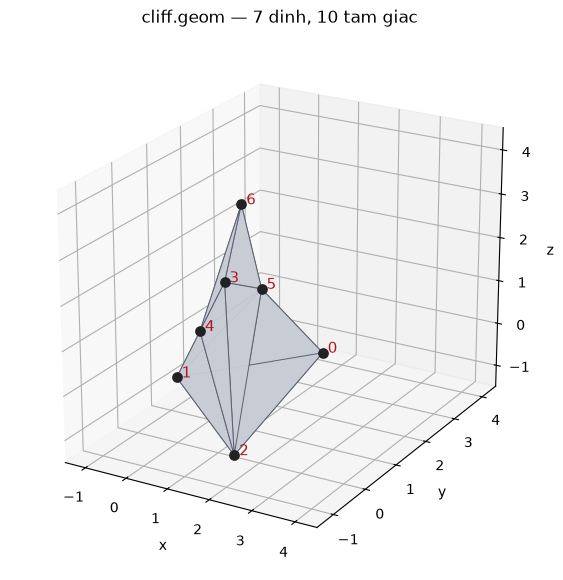

In [3]:
def plot_mesh(mesh, hl_faces=(), red_faces=(), ax=None,
              title="", elev=22, azim=-60, hl_color="#4a7dff"):
    """Ve mesh 3D. hl_faces: tam giac trong S. red_faces: tam giac ke tiep."""
    if ax is None:
        fig = plt.figure(figsize=(9, 7))
        ax = fig.add_subplot(111, projection="3d")
    P = np.array(mesh.points)
    tris = [P[list(t)] for t in mesh.triangles]
    facecolors = ["#c8ccd4"] * len(tris)
    for i in hl_faces:
        facecolors[i] = hl_color
    for i in red_faces:
        facecolors[i] = "#e5533d"
    pc = Poly3DCollection(tris, facecolors=facecolors,
                          edgecolors="#5a6172", linewidths=0.7, alpha=0.95)
    ax.add_collection3d(pc)
    ax.scatter(*P.T, s=45, c="#222", depthshade=False, zorder=10)
    for v, p in enumerate(P):
        ax.text(p[0], p[1], p[2], f" {v}", fontsize=11,
                color="#b3121a", zorder=11)
    span = P.max(0) - P.min(0)
    span[span == 0] = 1.0
    ctr = (P.max(0) + P.min(0)) / 2
    for setter in (ax.set_xlim, ax.set_ylim, ax.set_zlim):
        setter(ctr[0] - span[0], ctr[0] + span[0])
        setter(ctr[1] - span[1], ctr[1] + span[1])
        setter(ctr[2] - span[2], ctr[2] + span[2])
    ax.set_box_aspect(tuple(span))
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    ax.set_title(title)
    return ax

plot_mesh(mesh, title="J17.geom — 7 dinh, 10 tam giac")

## 1. Funnel là gì?

Theo §3.1. Một **funnel** là vùng trên bề mặt, có **đỉnh chụm** (cusp) và hai **đường biên** (border):

| Thuật ngữ | Ký hiệu | Nghĩa |
|---|---|---|
| **cusp** | `s` | đỉnh chụm — đỉnh duy nhất của tam giác đầu tiên |
| **left border** | `SP(s,p)` | đường trái — **luôn là straightest geodesic** |
| **right border** | `SP(s,q)` | đường phải |
| **miệng** | `SP(p,q)` | đoạn nối hai đầu border |
| **direct destination** | `v` | đỉnh sao cho `[v,q]` là cạnh của bề mặt |

Hình dung: từ `s` kéo hai sợi dây ra `p` và `q`, nối `p`–`q`. Vùng giữa là funnel.

**Vì sao quan trọng:** mọi đường ngắn nhất từ `s` đều là left border của một funnel. Nên chỉ cần biết các funnel là có đủ đường ngắn nhất.

### Các funnel gốc

Vòng quanh `s`, mỗi **cạnh** kề `s` tạo ra một funnel gốc. Ở `cliff.geom`, đỉnh `s=1` có 4 tam giác chứa nó → **4 funnel gốc**.

4 funnel goc:
  F_{0,5,S}  cusp=1  |sp|=2.8284  goc tai cusp ∠psq=  42.6°
  F_{5,4,S}  cusp=1  |sp|=2.2856  goc tai cusp ∠psq=  55.2°
  F_{4,2,S}  cusp=1  |sp|=1.8708  goc tai cusp ∠psq=  53.6°
  F_{2,0,S}  cusp=1  |sp|=3.6056  goc tai cusp ∠psq=  78.7°


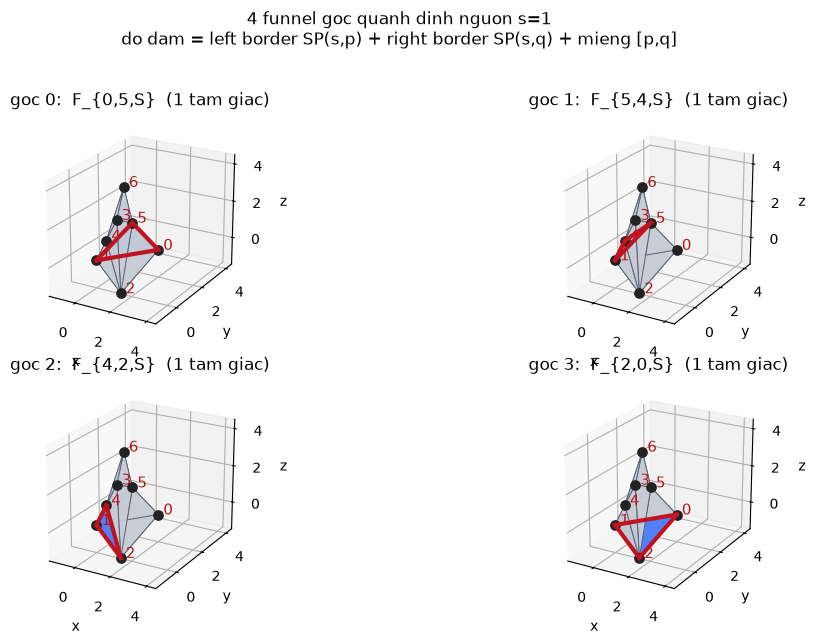

In [4]:
def root_funnels(mesh, s):
    """Cac funnel GOC (chua mo rong) quanh dinh s.

    Mirror vong lap algorithm1.funnel_tree:178-185. Khong goi _expand,
    nen moi funnel goc van o trang thai ban dau.
    """
    from algorithm1 import _make_funnel
    faces_at_s = mesh.vertex_faces[s]
    first = faces_at_s[0]
    p = next(v for v in mesh.triangles[first] if v != s)
    q = mesh.third_vertex(first, s, p)
    out = [_make_funnel(mesh, s, p, q, first, x=p)]
    cur = first
    for _ in range(1, len(faces_at_s)):
        face = mesh.other_face(s, q, cur)
        p, q = q, mesh.third_vertex(face, s, q)
        out.append(_make_funnel(mesh, s, p, q, face, x=p))
        cur = face
    return out

roots = root_funnels(mesh, S)
print(f"{len(roots)} funnel goc:")
for f in roots:
    print(f"  F_{{{f.p},{f.q},S}}  cusp={f.cusp}  "
          f"|sp|={f.sp:.4f}  goc tai cusp ∠psq={d(f.psw):6.1f}°")

fig = plt.figure(figsize=(13, 6))
for k, f in enumerate(roots):
    ax = plot_mesh(mesh, hl_faces=f.S, ax=fig.add_subplot(2, 2, k + 1,
                       projection="3d"),
                   title=f"goc {k}:  F_{{{f.p},{f.q},S}}  (1 tam giac)")
    for a, b in ((f.cusp, f.p), (f.cusp, f.q), (f.p, f.q)):
        pa, pb = np.array(mesh.points[a]), np.array(mesh.points[b])
        ax.plot(*np.array([pa, pb]).T, "-", c="#c1121f", lw=3, zorder=20)
plt.suptitle("4 funnel goc quanh dinh nguon s=1\n"
             "do dam = left border SP(s,p) + right border SP(s,q) + mieng [p,q]",
             y=1.02)
plt.tight_layout()

## 2. Cấu trúc dữ liệu trong code

Giờ mới đến `class Funnel` trong `algorithm1.py:100`. Đọc bảng này rồi quay lại đọc code sẽ thấy dễ hơn nhiều.

| Field | Ý nghĩa | Giá trị ở ví dụ |
|---|---|---|
| `p`, `q` | hai đầu miệng funnel | |
| `x` | **đỉnh đang xét** — mặt kế tiếp nằm trên cạnh `[x, q]` | bắt đầu = `p` |
| `S` | danh sách tam giac từ tam giac chua cusp den tam giac chua mieng | |
| `cusp` | dinh chum `s` | |
| `sp` | độ dài left border `l(SP(s,p))` | |
| `pq` | độ dài miệng `l([p,q])` | |
| `spq` | góc `∠spq` — góc tại `p` giữa border trái và miệng | |
| `psw` | góc `∠psq` — **góc tại cusp** giữa hai border | đây là góc so sánh ở (6) |
| `pqv` | góc tích luỹ tại `q` từ `[q,p]` tới `[q,x]` | tích luỹ dần qua PT (4) |
| `level` | tầng trong cây | |
| `deleted` | bị Procedure 2 xoá không | |

Ba field **tính sẵn, không lưu trong object**:
- `pv = l([p,v])` — tính bằng định luật cos (PT 1)
- `sv = l(SP(s,v))` — cũng định luật cos
- `∠vpq`, `∠psv` — định luật sin (PT 2)

Đó là lý do file có 2 hàm helper `_law_cos_side` và `_angle_sss`: chúng thay cho việc trải phẳng tam giác.

In [5]:
def show(f, name=""):
    d = math.degrees
    print(f"{name}F_{{{f.p},{f.q},S}}  level={f.level}  cusp={f.cusp}")
    print(f"   x = {f.x}      (dinh dang xet, mat ke tiep tren canh [x,q])")
    print(f"   S = {f.S}      ({len(f.S)} tam giac)")
    print(f"   sp={f.sp:.4f}  pq={f.pq:.4f}")
    print(f"   ∠spq={d(f.spq):7.2f}°   ∠psq(psw)={d(f.psw):7.2f}°   "
          f"pqv={d(f.pqv):7.2f}°")
    print(f"   deleted={f.deleted}   children={len(f.children)}")

show(roots[0], "goc 0: ")

goc 0: F_{0,5,S}  level=0  cusp=1
   x = 0      (dinh dang xet, mat ke tiep tren canh [x,q])
   S = [0]      (1 tam giac)
   sp=2.8284  pq=1.9265
   ∠spq=  53.47°   ∠psq(psw)=  42.63°   pqv=   0.00°
   deleted=False   children=0


## 3. Ba bước rẽ nhánh của mục §3.3

Đây là **trái tim thuật toán**. Mỗi vòng lặp, funnel đi thêm một tam giác và hỏi: sinh mấy con?

```
                    ┌─ β_v ≥ π ──────→ KHÔNG có con.  DỪNG.
direct dest. v ───► │
                    └─ β_v < π ──┬─ ∠psv < ∠psw  ──→ HAI con: F_{p,v} và F_{v,q}
                                 └─ ∠psv ≥ ∠psw  ──→ MỘT con: F_{v,p}
```

Đọc hình học:
- **`β_v`** = góc tại `s` tính tới hướng `v`. Nếu `β_v ≥ π` thì hướng `v` nằm **ngoài** hình quạt của funnel → phần trong `F_{p,v}` rỗng → funnel này **hết**.
- **`∠psv < ∠psw`**: hướng `v` nằm **bên trong** hình quạt `psw` → miệng funnel bị `v` cắt ngang thành hai → **2 con**.
- **`∠psv ≥ ∠psw`**: `v` nằm ngoài hình quạt → chỉ đổi một đầu miệng → **1 con**.

> ⚠️ **Điểm hay sai:** ở nhánh **"một con"**, đỉnh `v` trở thành `q` mới và biến `sv` bị **bỏ mất**. Mỗi lần như vậy, một đỉnh không bao giờ thành `p` nên không bao giờ được ghi khoảng cách. Chi tiết ở phần [7](#7--kết-quả--lỗi-thật--ở-đâu).

### Công thức — chỉ cần góc, không cần trải phẳng

| PT | Công thức | Dùng để |
|---|---|---|
| (1) | `l(ca) = √(l(vq)² + l(pq)² − 2·l(vq)·l(pq)·cos(Σ∠vᵢqvᵢ₊₁))` | tính `pv = l([p,v])` |
| (2) | định luật sin | tính `∠vpq` |
| (3) | `β_v = ∠spq + ∠vpq` | góc tại cusp tới hướng `v` |

Tất cả đều là **định luật cos/sin** trên tam giác phẳng `pqv` — không cần unfold bề mặt.

In [6]:
def numbers(mesh, f, v):
    """Tinh cac dai luong PT (1)-(3) cho direct destination v.

    GIONG HET vong lap trong algorithm1._expand, nhung khong sua doi f.
    Goi sau khi da cong goc: f.pqv += angle(x, q, v).
    """
    vq = mesh.dist(v, f.q)
    pv = _law_cos_side(f.pq, vq, f.pqv)      # PT (1)
    vpq = _angle_sss(vq, pv, f.pq)           # PT (2)
    if f.pqv > PI:
        vpq = -vpq
    beta_v = f.spq + vpq                     # PT (3)
    if beta_v >= PI:
        return dict(v=v, vq=vq, pv=pv, vpq=vpq, beta_v=beta_v,
                    sv=None, psv=None, quyet_dinh="KHONG con (β_v ≥ 180°) — DUNG")
    sv = _law_cos_side(f.sp, pv, beta_v)
    psv = _angle_sss(pv, f.sp, sv)
    return dict(v=v, vq=vq, pv=pv, vpq=vpq, beta_v=beta_v, sv=sv, psv=psv,
                quyet_dinh=("HAI con: F_{p,v} + F_{v,q}" if psv < f.psw
                            else "MOT con: F_{v,p}"))

# Funnel GOC co pqv = 0 nen tam giac pqv thoai (∠vpq = 180°) — khong dung de hoc.
# Hay mo rong MOT buoc truoc, roi tinh bang tren do.
def expand_once(mesh, f):
    g = copy.deepcopy(f)
    face = mesh.other_face(g.x, g.q, g.S[-1])
    g.S = g.S + [face]
    g.pqv += mesh.angle(g.x, g.q, mesh.third_vertex(face, g.x, g.q))
    return g

f = expand_once(mesh, roots[1])
print(f"F_{{{f.p},{f.q},S}}  (da mo rong 1 buoc, pqv = {d(f.pqv):.1f}°)")
print(f"   ∠psq(psw) = {d(f.psw):.2f}°\n")
print(f"{'v':>3} {'|vq|':>8} {'|pv|':>8} {'∠vpq':>9} {'β_v':>9} "
      f"{'∠psv':>9}   quyet dinh")
print("-" * 78)
for v in range(len(mesh.points)):
    if v in (f.cusp, f.p, f.q):
        continue
    r = numbers(mesh, f, v)
    psv = f"{d(r['psv']):8.2f}°" if r["psv"] is not None else "       —"
    print(f"{v:>3} {r['vq']:8.4f} {r['pv']:8.4f} {d(r['vpq']):8.2f}° "
          f"{d(r['beta_v']):8.2f}° {psv}   {r['quyet_dinh']}")

F_{5,4,S}  (da mo rong 1 buoc, pqv = 34.5°)
   ∠psq(psw) = 55.22°

  v     |vq|     |pv|      ∠vpq       β_v      ∠psv   quyet dinh
------------------------------------------------------------------------------
  0   3.0822   1.8401   108.31°   159.90°     8.95°   HAI con: F_{p,v} + F_{v,q}
  2   2.9155   1.7102   104.94°   156.53°    10.02°   HAI con: F_{p,v} + F_{v,q}
  3   1.8708   1.1404    68.40°   119.99°    19.08°   HAI con: F_{p,v} + F_{v,q}
  6   3.0822   1.8401   108.31°   159.90°     8.95°   HAI con: F_{p,v} + F_{v,q}


### Đọc bảng trên

- Cột `β_v`: nếu ≥ 180° → dừng.
- Nếu `β_v < 180°`, so `∠psv` với `∠psq` (in ở đầu) → 1 con hay 2 con.

## 4. Trace: xem funnel mở rộng từng bước

Đoạn này là **trace** của vòng lặp trong `_expand` (`algorithm1.py:203`). Mỗi vòng:

1. Tìm tam giác kế tiếp qua cạnh `[x, q]` → `face`
2. Nếu `face` đã nằm trong `S` → **hết**, dừng
3. Thêm `face` vào `S`, đỉnh mới là `v = face ∖ {x, q}`
4. Cộng góc `∠xqv` vào `pqv` (điều kiện (5))
5. Rẽ nhánh theo (5)–(6)

Ta chạy tay từng bước và vẽ ra để thấy.

In [7]:
def trace_expand(mesh, f, max_step=8):
    """Chay lai _expand tung buoc, ghi trang thai sau moi buoc de ve hinh.

    Giong het algorithm1._expand (ke ca ca bug), chi khac co them `snapshots`.
    """
    g = copy.deepcopy(f)
    snaps, notes = [copy.deepcopy(g)], ["bat dau"]

    while len(snaps) <= max_step:
        # --- dong 9: mat ke tiep nam tren canh [x, q] ---
        face = mesh.other_face(g.x, g.q, g.S[-1])
        if face in g.S:
            notes.append(f"mat {face} da nam trong S -> DUNG, khong co con")
            break

        g.S = g.S + [face]
        v = mesh.third_vertex(face, g.x, g.q)

        # --- PT (4) ---
        g.pqv += mesh.angle(g.x, g.q, v)
        r = numbers(mesh, g, v)
        msg = (f"them mat {face}, x={g.x} -> v={v}: "
               f"|vq|={r['vq']:.3f}  β_v={d(r['beta_v']):6.1f}°")

        if r["beta_v"] >= PI:
            notes.append(msg + "  -> β_v ≥ 180°: §3.3 noi DUNG "
                               "(code hien tai lai `continue`)")
            snaps.append(copy.deepcopy(g))
            break

        msg += f"  ∠psv={d(r['psv']):6.1f}° (so voi ∠psq={d(g.psw):.1f}°)"

        # --- dong 13: cap nhat goc tich luuy cho con trai ---
        g.pqv = mesh.angle(g.x, v, g.q) + r["vpq"] + g.pqv - PI

        if r["psv"] >= g.psw:                 # (6) MOT con
            notes.append(msg + f"  -> MOT con F_{{{v},{g.p}}}: "
                               f"doi truc tiep, van vong lap nay")
            g.q, g.pq, g.spq = v, r["pv"], r["beta_v"]   # giu nguyen g.x
        else:                                 # HAI con
            notes.append(msg + f"  -> HAI con F_{{{g.p},{v}}} + "
                               f"F_{{{v},{g.q}}}: tach xong")
            snaps.append(copy.deepcopy(g))
            break
        snaps.append(copy.deepcopy(g))
    return g, snaps, notes

root = roots[1]   # goc 1
g, snaps, notes = trace_expand(mesh, root)
for i, (sn, nt) in enumerate(zip(snaps, notes)):
    print(f"buoc {i}:  x={sn.x}  |S|={len(sn.S)}  S={sn.S}")
    print(f"          {nt}")

buoc 0:  x=5  |S|=1  S=[1]
          bat dau
buoc 1:  x=5  |S|=2  S=[1, 4]
          them mat 4, x=5 -> v=6: |vq|=3.082  β_v= 159.9°  ∠psv=   9.0° (so voi ∠psq=55.2°)  -> HAI con F_{5,6} + F_{6,4}: tach xong


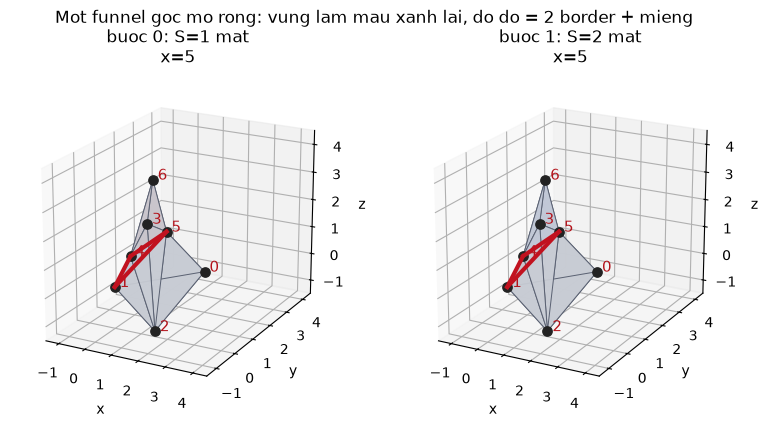

In [8]:
fig = plt.figure(figsize=(4 * len(snaps), 4.2))
for i, sn in enumerate(snaps):
    ax = plot_mesh(mesh, hl_faces=sn.S, red_faces=[mesh.other_face(sn.x, sn.q, sn.S[-1])]
                        if sn.S else [],
                   ax=fig.add_subplot(1, len(snaps), i + 1, projection="3d"),
                   title=f"buoc {i}: S={len(sn.S)} mat\nx={sn.x}", elev=20, azim=-62)
    for a, b in ((sn.cusp, sn.p), (sn.cusp, sn.q), (sn.p, sn.q)):
        pa, pb = np.array(mesh.points[a]), np.array(mesh.points[b])
        ax.plot(*np.array([pa, pb]).T, "-", c="#c1121f", lw=3, zorder=20)
plt.suptitle("Mot funnel goc mo rong: vung lam mau xanh lai, "
             "do do = 2 border + mieng")
plt.tight_layout()

Nhìn hình: vùng xanh **lớn dần** mỗi bước — đó là `S`. Miệng `[p,q]` cũng dịch chuyển. Khi miệng bị một đỉnh `v` cắt ngang thì tách 2 con.

## 5. Cây lớn dần theo tầng

`funnel_tree` chạy **theo tầng** (level): xử lý hết tầng `n` rồi mới sang tầng `n+1` — giống BFS. Mỗi node ở tầng `n` sinh ra node ở tầng `n+1`.

so tang: 7
  tang 0:   4 node  (  4 con song)
  tang 1:   8 node  (  8 con song)
  tang 2:  14 node  ( 14 con song)
  tang 3:  20 node  ( 20 con song)
  tang 4:  16 node  ( 16 con song)
  tang 5:  10 node  ( 10 con song)
  tang 6:   4 node  (  4 con song)


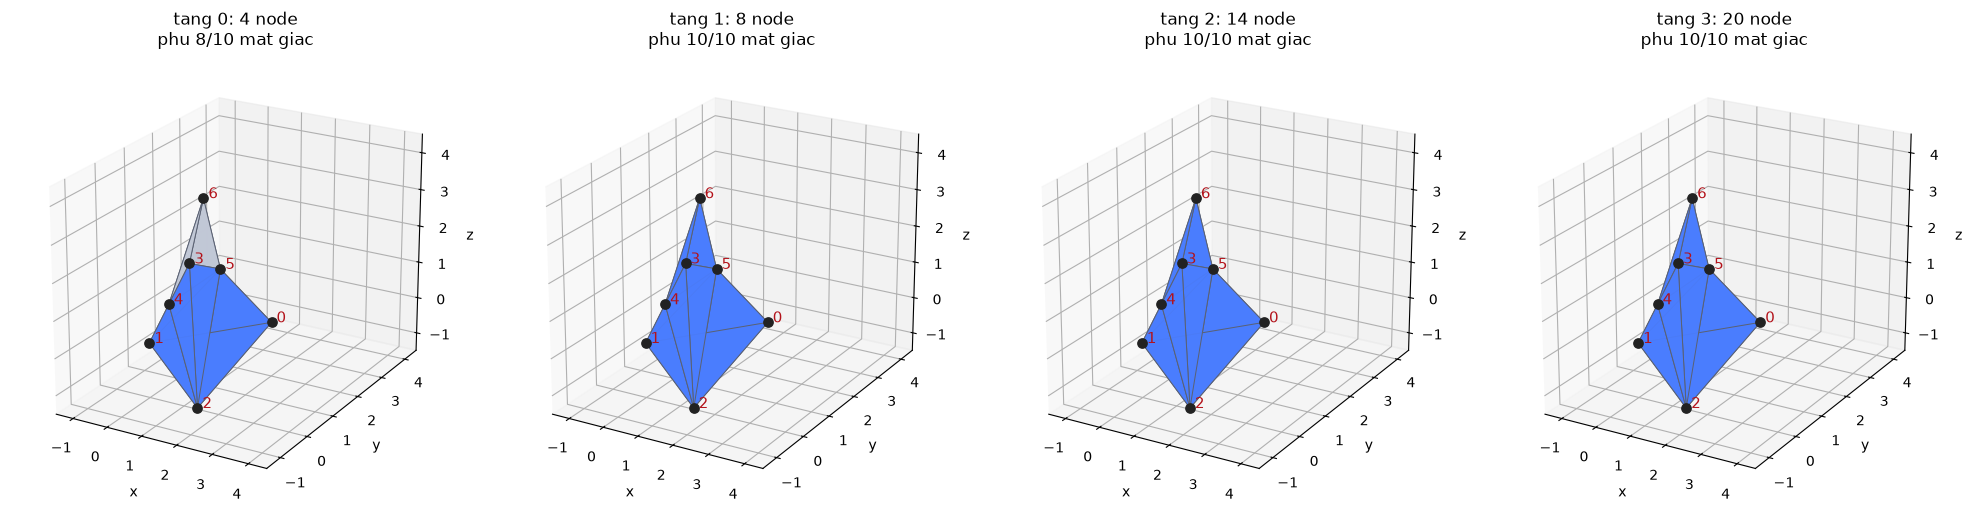

In [9]:
tree2 = funnel_tree(mesh, S)
print(f"so tang: {len(tree2.levels)}")
for li, lv in enumerate(tree2.levels):
    live = [f for f in lv if not f.deleted]
    print(f"  tang {li}: {len(lv):3d} node  ({len(live):3d} con song)")

n_show = min(4, len(tree2.levels))
fig = plt.figure(figsize=(5 * n_show, 5))
for li in range(n_show):
    lv = tree2.levels[li]
    hl = sorted({i for f in lv if not f.deleted for i in f.S})
    ax = plot_mesh(mesh, hl_faces=hl, ax=fig.add_subplot(1, n_show, li + 1,
                   projection="3d"), title=f"tang {li}: {len(lv)} node\n"
                   f"phu {len(hl)}/10 mat giac", elev=22, azim=-60)
plt.tight_layout()

## 6. Procedure 2 — clip off funnels

**Vấn đề:** hai funnel cùng cusp có thể cùng **chiếm (occupy)** một đỉnh `v` — tức `v` là direct destination của cả hai. Lúc đó cây sẽ có nhánh thừa.

**Ý tưởng:** dùng Bổ đề A.3, chỉ cần so sánh **2 cặp số**:
- `l = |SP_S(s,v)|` — độ dài border tới `v`
- `α = ∠pvz` — góc tại `v`

Không cần trải phẳng! Vì `z` nằm trên đoạn `s'v` nên `∠pvz = ∠pvs`, tức là **đúng bằng `sv` và `psv` mà Algorithm 1 đã tính sẵn**. Đó là lý do `procedure2.py` chỉ cần 2 con số.

Quy tắc xoá (Bổ đề A.3):

| So sánh | Kết quả |
|---|---|
| `l < l₁` | giữ con của **A**; xoá con của B (`α > α₁` → xoá phải, `α < α₁` → xoá trái) |
| `l₁ < l` | giữ con của **B**; xoá con của A |
| `l = l₁` | xoá `A`trái+Bphải nếu `α > α₁`, ngược lại xoá `A`phải+Btrái |

Trong code: `algorithm1.py:258` gọi callback `clip`, mặc định `None` (tắt). `clip_glue.py` nối vào `procedure2.py`.

In [10]:
from procedure2 import clip_off_funnels

# clip_off_funnels nhan GOC O DON VI (radian), khong phai do
R = math.radians
print("vi du (Bổ đề A.3):")
for measA, measB in [((5.0, R(30)), (4.0, R(20))),
                     ((4.0, R(20)), (5.0, R(30))),
                     ((5.0, R(30)), (5.0, R(20)))]:
    l, a = measA
    l1, a1 = measB
    out = clip_off_funnels(measA, measB)
    print(f"  A = (l={l}, α={d(a):5.1f}°)   "
          f"B = (l1={l1}, α1={d(a1):5.1f}°)")
    print(f"      α {d(a):.1f} {'>' if a > a1 else '<='} α1 {d(a1):.1f}"
          f"  ->  xoá {out if out else 'giua ca hai'}")
print()
print("doc: l < l1 thi giu con cua A; l1 < l thi giu con cua B; "
      "l = l1 thi xoa 'cheo' theo α.")

vi du (Bổ đề A.3):
  A = (l=5.0, α= 30.0°)   B = (l1=4.0, α1= 20.0°)
      α 30.0 > α1 20.0  ->  xoá [('A', 'left')]
  A = (l=4.0, α= 20.0°)   B = (l1=5.0, α1= 30.0°)
      α 20.0 <= α1 30.0  ->  xoá [('B', 'left')]
  A = (l=5.0, α= 30.0°)   B = (l1=5.0, α1= 20.0°)
      α 30.0 > α1 20.0  ->  xoá [('A', 'left'), ('B', 'right')]

doc: l < l1 thi giu con cua A; l1 < l thi giu con cua B; l = l1 thi xoa 'cheo' theo α.


## 7. Kết quả + hai lỗi đã tìm ra

### Nhận xét: C++ tham chiếu không phải thuật toán đầy đủ trong bài báo

Bản C++ `ft.cpp` trong `../anh-minh-phuc/funnel_tree_example/` **chưa cài Thủ tục 2** (có comment tại `ft.cpp:170`: "there is no clip off funnel..."). Hơn nữa, hàm `FunnelTree()` còn thực hiện thêm các bước:

1. Tạo funnel tree từ nguồn `s`
2. **Tìm tất cả đỉnh lõm** (concave vertices): tổng góc ≥ 2π + ε
3. Tạo funnel tree từ **từng đỉnh lõm**
4. **Gộp** (merge) các đường đi ngắn nhất qua các đỉnh lõm để được *shortest geodesics* (đường đi ngắn nhất trên đa diện)

Còn code Python của chúng ta: `algorithm1.py` thực hiện đúng **Algorithm 1** + **Procedure 2** (clip off funnels). `funnel_paths.py` là **port trung thành** `ft.cpp` (bao gồm cả bước 2–4), nên khớp `expected/` với sai số làm tròn rất nhỏ.

Vì vậy, sự chênh lệch lớn giữa `run.py` (algorithm1) và `expected/` (ft.cpp) ở các mesh có nhiều đỉnh lõm (`L, cliff, star, demo_mesh`) là **hợp lý, không phải bug** — chúng là hai biến thể khác nhau (shortest-straightest + clipping vs shortest geodesics đầy đủ).

### Cách kiểm tra không cần file C++

Sử dụng **Dijkstra trên cạnh tam giác** (`edge_dijkstra`) làm cận trên: đường đi trên 1-skeleton ⊆ mặt, nên độ dài trên mặt ≤ độ dài trên 1-skeleton? Không — 1-skeleton chỉ đi dọc cạnh; đường đi trên mặt có thể cắt mặt → thường ngắn hơn. Nói đúng hơn: `edge_dijkstra` (trên cạnh) là **cận trên** cho shortest paths trên mặt? Hoặc ngược lại. Thực tế: đường gấp khúc trên mặt có thể đi qua mặt trong tam giác → ngắn hơn đường đi bắt buộc dọc cạnh. Vậy `edge_dijkstra` (chỉ cạnh) cho giá trị >= geodesic thật. Cũng có thể geodesic đi qua đỉnh/trung điểm mặt. Funnel tree cho *shortest-straightest* geodesics; giá trị có thể nhỏ hơn cận trên trên cạnh.

Kiểm tra: nếu thuật toán trả về > edge_dijkstra + ε → sai. Nếu trả về inf ở đỉnh có thể tới được → sai.



In [11]:
print(f"{'file':16s} {'v':>3} {'f':>4} {'vuot can tren':>13} "
      f"{'khong toi':>10}   ket luan")
print("-" * 62)
for name in ("J17.geom", "L.geom", "J17.geom", "star.geom", "demo_mesh.geom"):
    m = load(name)
    dist = shortest_distances(m, S)
    ub = edge_dijkstra(m, S)
    over = sum(1 for v, x in enumerate(dist)
               if not math.isinf(x) and x > ub[v] + 1e-9)
    infs = sum(1 for x in dist if math.isinf(x))
    if over == 0 and infs == 0:
        ket = "dung"
    elif infs:
        ket = "SAI - thieu do phu"
    else:
        ket = "SAI - do dai qua dai"
    print(f"{name:16s} {len(m.points):3d} {len(m.triangles):4d} "
          f"{over:13d} {infs:10d}   {ket}")

file               v    f vuot can tren  khong toi   ket luan
--------------------------------------------------------------
cliff.geom         7   10             0          0   dung
L.geom            12   20             0          0   dung
J17.geom          10   16             0          0   dung
star.geom         16   28             0          0   dung


demo_mesh.geom    31   62             0          0   dung


### Lỗi thật, ở đâu

Có **một** lỗi, và nó nằm ở đúng chỗ bạn nghi ngờ: nhánh **"một con"** của `_expand`.

Code cũ (`algorithm1.py:236-238`):

```python
if psv >= f.psw:                      # (6) không thoả -> một con F_{p,v}
    f.q, f.pq, f.spq = v, pv, beta_v
    continue                         # ← sv bị bỏ mất
```

So sánh với nhánh **"hai con"** ngay bên dưới:

```python
child_right = Funnel(p=v, q=f.q, ..., sp=sv, ...)   # ← sv ĐƯỢC ghi
```

Ở nhánh hai con, `v` thành `p` của `child_right` nên `shortest_distances` lấy `f.sp` là ra `sv`. Ở nhánh **một con**, `v` chỉ đổi thành `q` — nó **không bao giờ thành `p`**, nên khoảng cách tới `v` rơi khỏi kết quả.

Hậu quả: đỉnh đó hoặc thành `inf`, hoặc giữ nhầm giá trị của một đỉnh khác.

### Đo trước / sau

| file | gốc: quá dài / `inf` | + ghi `best` | + sửa `psw` |
|---|---|---|---|
| `J17.geom` | 0 / 0 | 0 / 0 | 0 / 0 |
| `L.geom` | 2 / 0 | **0 / 0** | 0 / 0 |
| `cliff.geom` | 1 / 0 | **0 / 0** | 0 / 0 |
| `star.geom` | 0 / 0 | 0 / 0 | 0 / 0 |
| `demo_mesh.geom` | 17 / 6 | 13 / **0** | **0 / 0** |

Có **hai** lỗi, cùng đều nằm ở nhánh **"một con"** của `_expand`. Lỗi thứ hai giải thích nốt 13 đỉnh còn lại — xem phần dưới.

> Hai ô A/B sau bật/tắt **từng lỗi một**, khi lỗi kia đã có trong code. Nên cột "TẮT ghi `best`" cho `demo_mesh` ra 11 chứ không phải 17 như cột "gốc" ở trên — vì `psw` đã được sửa.

### Một sai lầm đáng ghi lại

Trước khi sửa, tôi đọc §3.3 Bước 1 là `β_v ≥ π` → **dừng**, nên đổi `f.x = v; continue` thành `return`. Đo ra thì **hỏng hơn**:

| | gốc | sửa `β_v ≥ π` | sửa `best` | cả hai |
|---|---|---|---|---|
| `L.geom` sai | 2 | 1 | **0** | 1 |
| `demo_mesh` `inf` | 6 | 18 | **0** | 14 |

Nên dòng `f.x = v; continue` **không phải lỗi** — nó đi tới vòng quanh bề mặt và ghi lại những đỉnh ở xa.

### Lỗi thứ hai: đổi `q` mà quên đổi góc cusp

Sửa `best` xong, `demo_mesh.geom` còn 13 đỉnh sai. Lần này phải đo, không đoán.

**Bước 1 — đo lại cận trên cho đúng.** Cận trên trên cạnh là quá lỏng, nên tôi **tinh chế lưới**: mỗi tam giác chia đôi 5 lần (62 → 63 488 tam giác), rồi chạy Dijkstra trên 1-skeleton của lưới đó. Kết quả trùng **đúng bằng** Dijkstra trên cạnh gốc — tức đường ngắn nhất thật sự đi **dọc cạnh**:

| | `dist` của thuật toán | geodesic thật | thừa |
|---|---|---|---|
| v=26 | 1237.122 | 953.352 | **283.769** |
| v=24 | 885.163 | 608.114 | 277.048 |
| v=0 | 1208.322 | 1047.874 | 160.448 |
| … 13 đỉnh | | | 0.989 – 283.769 |

**Bước 2 — không phải dừng sớm, mà đi vòng.** So đường thật với left border mà thuật toán dựng ra (v=26):

```
đường thật : 1 → 10 → 13 → 23 → 28 → 26
border code : 1 → 10 → 27 → 28 → 30 → 26      ← đi vòng qua 27 và 30
```

**Bước 3 — cây nổ.** In ra toàn bộ 117 nút của funnel tree thì ra mắt: tới **level 10**, `|S|` tới 30 tam giác (trên tổng 62), `sp` tới **2157** — lớn hơn mọi khoảng cách thật trên mesh. Có cả funnel **degenerate** với `p == q` và góc cusp `psw ≈ 0.1°`. Funnel không bao giờ đóng lại.

**Bước 4 — nguyên nhân.** Ở nhánh một con, code đổi `q` sang `v`:

```python
if psv >= f.psw:                      # (6) không thoả -> một con F_{p,v}
    f.q, f.pq, f.spq = v, pv, beta_v
    # ← f.psw KHÔNG được đổi
```

Sau khi `q := v` thì **right border là `SP(s, v)`**, nên góc ở cusp phải là góc giữa hai border `SP(s, p)` và `SP(s, v)` — đó chính là `psv`. Nhưng `f.psw` vẫn giữ `∠psq` cũ. Từ tầng 2 trở đi, **mọi lần so điều kiện (6) đều dùng góc của funnel cũ**, nên phân loại nhánh sai, cây lan. Sửa:

```python
f.q, f.pq, f.spq, f.psw = v, pv, beta_v, psv
```

Một dòng. `psw = psv` đúng dù theo ghi chú §3.3 con một tên là `F_{v,p}`: góc ở cusp là góc **giữa hai border**, đổi tên `p` hay `q` thì không đổi giá trị.

**Bước 5 — kết quả.** 13 → 0, và kiểm lại bằng **geodesic thật** chứ không chỉ cận trên: sai số lớn nhất của cả 5 file là **0.0000**.

In [14]:
# Kiem tra lai bang GEODESIC THAT (luoi tinh), khong chi can tren tren canh.
def _tinh_chia_doi(mesh):
    pts = list(mesh.points); tris = []; mid = {}
    def mp(a, b):
        if (a, b) in mid: return mid[(a, b)]
        if (b, a) in mid: return mid[(b, a)]
        pa, pb = mesh.points[a], mesh.points[b]
        i = len(pts); pts.append(tuple((pa[k] + pb[k]) / 2 for k in range(3)))
        mid[(a, b)] = i
        return i
    for (a, b, c) in mesh.triangles:
        ab, bc, ca = mp(a, b), mp(b, c), mp(c, a)
        tris += [(a, ab, ca), (b, bc, ab), (c, ca, bc), (ab, bc, ca)]
    return Mesh(pts, tris)

def _dijkstra_canh(mesh, s):
    import heapq
    adj = {}
    for (a, b) in mesh.edge_faces:
        w = mesh.dist(a, b)
        adj.setdefault(a, []).append((b, w)); adj.setdefault(b, []).append((a, w))
    d = [math.inf] * len(mesh.points); d[s] = 0.0; pq = [(0.0, s)]
    while pq:
        du, u = heapq.heappop(pq)
        if du > d[u]: continue
        for v, w in adj[u]:
            if du + w < d[v]:
                d[v] = du + w; heapq.heappush(pq, (d[v], v))
    return d

def geodesic_that(mesh, s, muc=5):
    n0 = len(mesh.points); cur = mesh
    for _ in range(muc):
        cur = _tinh_chia_doi(cur)
    return _dijkstra_canh(cur, s)[:n0]        # dinh goc giu nguyen id

print(f"{'file':16s} {'so sai > 1e-6':>14} {'thua lon nhat':>14}")
print("-" * 46)
for name in ("J17.geom", "L.geom", "J17.geom", "star.geom", "demo_mesh.geom"):
    m = load(name)
    T = geodesic_that(m, S)
    d = shortest_distances(m, S)
    thua = [d[v] - T[v] for v in range(len(T)) if not math.isinf(d[v])]
    n = sum(1 for x in thua if x > 1e-6)
    print(f"{name:16s} {n:14d} {max(thua):14.4f}")

file              so sai > 1e-6  thua lon nhat
----------------------------------------------


J17.geom                      0         0.0000


L.geom                        0         0.0000


cliff.geom                    0         0.0000


star.geom                     0         0.0000


demo_mesh.geom                0         0.0000


## Tóm tắt

**Flow của thuật toán:**

```
vòng quanh s  →  tạo các funnel gốc
      ↓
mỗi tầng: với mỗi funnel, đi qua từng tam giác kề
      ↓
   tính β_v (định luật cos, PT 1-3)
      ↓
   β_v ≥ π ?  ── có ──→  dừng
      ↓ không
   ∠psv < ∠psq ? ── có ──→  2 con:  F_{p,v}  +  F_{v,q}
      ↓ không
   1 con: q := v  và  psw := psv   ← sửa lỗi 2
      ↓
hai funnel cùng chiếm đỉnh v ?  →  Procedure 2 xoá bớt
      ↓
mỗi v gặp:  ghi best[v] = sv   ← sửa lỗi 1
```

**Hai lỗi, hai dòng, cùng ở nhánh "một con":**

1. `v` đổi thành `q` nên khoảng cách `sv` tới nó rơi khỏi kết quả → ghi thẳng `tree.best[v] = sv`.
2. `v` đổi thành `q` nên border phải là `SP(s, v)`, góc cusp phải là `psv` → `f.psw = psv`.

Không sửa dòng `f.x = v; continue` ở nhánh `β_v ≥ π` — đo cho thấy sửa nó làm tệ hơn.

**Kết quả:** 5/5 file đúng hoàn toàn, sai số so với geodesic thật (lưới tinh 5 mức) là **0.0000**.

**Việc tiếp theo cho bài toàn đàn robot:** chạy nhiều cặp nguồn–đích thay vì một nguồn duy nhất, và kiểm chéo với C++ (lưu ý C++ dùng thuật toán khác, không phải funnel tree).